In [ ]:
import os
import sys

# 実行環境の確認
if "google.colab" in sys.modules:
    print("✓ Running in Google Colab")
else:
    print("✗ Running locally (not Colab)")

print(f"Python version: {sys.version}")
print(f"Executable: {sys.executable}")
print(f"Working Directory: {os.getcwd()}")

In [ ]:
# Colab で実行している場合、リポジトリをクローンする
#!git clone -b dev https://github.com/AcademiXBase/deep-learning-from-scratch.git
#%cd deep-learning-from-scratch/my_notebooks
#print(f"Current Working Directory: {os.getcwd()}")

In [ ]:
# -----------------------------
# Standard library
# -----------------------------
import pickle
from collections import OrderedDict

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定

# -----------------------------
# Third-party libraries
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from scipy.ndimage import rotate, shift, zoom

# -----------------------------
# Local modules
# -----------------------------
from common.layers import *
from common.trainer import Trainer
from dataset.mnist import load_mnist

# 第8章 ディープラーニングの学習

この章では、ネットワークを深くすることの利点やさらに認識精度を高めるための手法、ディープラーニングの応用例について実験と可視化を通して学ぶ

## 1. ディープなネットワークの構築

ここでは、MNIST データセットに対して 99 % を超える精度を達成するために、図 8-1 に示すようなディープな CNN を構築する

### 実装の特徴

- 3×3 の小さなフィルターによる畳み込み層を連続して使用  

- 活性化関数に ReLU を採用  

- 過学習抑制のための Dropout レイヤの挿入  

- Adam による最適化  

- 重みの初期値に He の初期値を使用  

| No | Layer | 入力サイズ (C, H, W) | 出力サイズ (C, H, W) | 備考 |
|----|------|----------------------|----------------------|------|
| 0 | Input | (1, 28, 28) | (1, 28, 28) |  |
| 1 | Conv1 (3x3, pad=1, 16ch) | (1, 28, 28) | (16, 28, 28) | サイズ維持 |
| 2 | ReLU | (16, 28, 28) | (16, 28, 28) |  |
| 3 | Conv2 (3x3, pad=1, 16ch) | (16, 28, 28) | (16, 28, 28) |  |
| 4 | ReLU | (16, 28, 28) | (16, 28, 28) |  |
| 5 | Pool (2x2) | (16, 28, 28) | (16, 14, 14) | 1/2に縮小 |
| 6 | Conv3 (3x3, pad=1, 32ch) | (16, 14, 14) | (32, 14, 14) |  |
| 7 | ReLU | (32, 14, 14) | (32, 14, 14) |  |
| 8 | Conv4 (3x3, pad=2, 32ch) | (32, 14, 14) | (32, 16, 16) | サイズ増加 |
| 9 | ReLU | (32, 16, 16) | (32, 16, 16) |  |
| 10 | Pool (2x2) | (32, 16, 16) | (32, 8, 8) | 1/2に縮小 |
| 11 | Conv5 (3x3, pad=1, 64ch) | (32, 8, 8) | (64, 8, 8) |  |
| 12 | ReLU | (64, 8, 8) | (64, 8, 8) |  |
| 13 | Conv6 (3x3, pad=1, 64ch) | (64, 8, 8) | (64, 8, 8) |  |
| 14 | ReLU | (64, 8, 8) | (64, 8, 8) |  |
| 15 | Pool (2x2) | (64, 8, 8) | (64, 4, 4) | 1/2に縮小 |
| 16 | Flatten | (64, 4, 4) | (1024) | 64×4×4 |
| 17 | Affine1 | (1024) | (50) | 全結合 |
| 18 | ReLU | (50) | (50) |  |
| 19 | Dropout | (50) | (50) |  |
| 20 | Affine2 | (50) | (10) | 出力 |
| 21 | Dropout | (10) | (10) |  |
| 22 | Softmax | (10) | (10) | 確率 |

# ch08/deep_convnet.py

In [ ]:
class DeepConvNet:
    """認識率99%以上の高精度なConvNet

    ネットワーク構成は下記の通り
        conv - relu - conv- relu - pool -
        conv - relu - conv- relu - pool -
        conv - relu - conv- relu - pool -
        affine - relu - dropout - affine - dropout - softmax
    """
    def __init__(self, input_dim=(1, 28, 28),
                 conv_param_1 = {'filter_num':16, 'filter_size':3, 'pad':1, 'stride':1},
                 conv_param_2 = {'filter_num':16, 'filter_size':3, 'pad':1, 'stride':1},
                 conv_param_3 = {'filter_num':32, 'filter_size':3, 'pad':1, 'stride':1},
                 conv_param_4 = {'filter_num':32, 'filter_size':3, 'pad':2, 'stride':1},
                 conv_param_5 = {'filter_num':64, 'filter_size':3, 'pad':1, 'stride':1},
                 conv_param_6 = {'filter_num':64, 'filter_size':3, 'pad':1, 'stride':1},
                 hidden_size=50, output_size=10):
        # 重みの初期化===========
        # 各層のニューロンひとつあたりが、前層のニューロンといくつのつながりがあるか（TODO:自動で計算する）
        pre_node_nums = np.array([1*3*3, 16*3*3, 16*3*3, 32*3*3, 32*3*3, 64*3*3, 64*4*4, hidden_size])
        weight_init_scales = np.sqrt(2.0 / pre_node_nums)  # ReLUを使う場合に推奨される初期値
        
        self.params = {}
        pre_channel_num = input_dim[0]
        for idx, conv_param in enumerate([conv_param_1, conv_param_2, conv_param_3, conv_param_4, conv_param_5, conv_param_6]):
            self.params['W' + str(idx+1)] = weight_init_scales[idx] * np.random.randn(conv_param['filter_num'], pre_channel_num, conv_param['filter_size'], conv_param['filter_size'])
            self.params['b' + str(idx+1)] = np.zeros(conv_param['filter_num'])
            pre_channel_num = conv_param['filter_num']
        self.params['W7'] = weight_init_scales[6] * np.random.randn(64*4*4, hidden_size)
        self.params['b7'] = np.zeros(hidden_size)
        self.params['W8'] = weight_init_scales[7] * np.random.randn(hidden_size, output_size)
        self.params['b8'] = np.zeros(output_size)

        # レイヤの生成===========
        self.layers = []
        self.layers.append(Convolution(self.params['W1'], self.params['b1'], 
                           conv_param_1['stride'], conv_param_1['pad']))
        self.layers.append(Relu())
        self.layers.append(Convolution(self.params['W2'], self.params['b2'], 
                           conv_param_2['stride'], conv_param_2['pad']))
        self.layers.append(Relu())
        self.layers.append(Pooling(pool_h=2, pool_w=2, stride=2))
        self.layers.append(Convolution(self.params['W3'], self.params['b3'], 
                           conv_param_3['stride'], conv_param_3['pad']))
        self.layers.append(Relu())
        self.layers.append(Convolution(self.params['W4'], self.params['b4'],
                           conv_param_4['stride'], conv_param_4['pad']))
        self.layers.append(Relu())
        self.layers.append(Pooling(pool_h=2, pool_w=2, stride=2))
        self.layers.append(Convolution(self.params['W5'], self.params['b5'],
                           conv_param_5['stride'], conv_param_5['pad']))
        self.layers.append(Relu())
        self.layers.append(Convolution(self.params['W6'], self.params['b6'],
                           conv_param_6['stride'], conv_param_6['pad']))
        self.layers.append(Relu())
        self.layers.append(Pooling(pool_h=2, pool_w=2, stride=2))
        self.layers.append(Affine(self.params['W7'], self.params['b7']))
        self.layers.append(Relu())
        self.layers.append(Dropout(0.5))
        self.layers.append(Affine(self.params['W8'], self.params['b8']))
        self.layers.append(Dropout(0.5))
        
        self.last_layer = SoftmaxWithLoss()

    def predict(self, x, train_flg=False):
        for layer in self.layers:
            if isinstance(layer, Dropout):
                x = layer.forward(x, train_flg)
            else:
                x = layer.forward(x)
        return x

    def loss(self, x, t):
        y = self.predict(x, train_flg=True)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        acc = 0.0

        for i in range(int(x.shape[0] / batch_size)):
            tx = x[i*batch_size:(i+1)*batch_size]
            tt = t[i*batch_size:(i+1)*batch_size]
            y = self.predict(tx, train_flg=False)
            y = np.argmax(y, axis=1)
            acc += np.sum(y == tt)

        return acc / x.shape[0]

    def gradient(self, x, t):
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        tmp_layers = self.layers.copy()
        tmp_layers.reverse()
        for layer in tmp_layers:
            dout = layer.backward(dout)

        # 設定
        grads = {}
        for i, layer_idx in enumerate((0, 2, 5, 7, 10, 12, 15, 18)):
            grads['W' + str(i+1)] = self.layers[layer_idx].dW
            grads['b' + str(i+1)] = self.layers[layer_idx].db

        return grads

    def save_params(self, file_name="params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name="params.pkl"):
        with open(file_name, 'rb') as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, layer_idx in enumerate((0, 2, 5, 7, 10, 12, 15, 18)):
            self.layers[layer_idx].W = self.params['W' + str(i+1)]
            self.layers[layer_idx].b = self.params['b' + str(i+1)]


## 2. 誤認識された画像の可視化

高い認識精度を持つネットワークでも依然として誤った予測を行っている  

どのような画像を間違えているのかを視覚的に確認することはモデルの改善において重要  

# ch08/train_deepnet.py

In [ ]:
"""
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False)

sampled = 10000 # 高速化のため
x_test = x_test[:sampled]
t_test = t_test[:sampled]

network = DeepConvNet()  
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=20, mini_batch_size=100,
                  optimizer="Adam", optimizer_param={"lr": 0.001},
                  evaluate_sample_num_per_epoch=1000, verbose=True)
trainer.train()

# パラメータの保存
network.save_params("../ch08/deep_convnet_params_test.pkl")
print("Saved Network Parameters!")
"""

# ch08/misclassified_mnist.py

In [ ]:
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False)

network = DeepConvNet()
network.load_params("../ch08/deep_convnet_params.pkl")

print("calculating test accuracy ... ")
#sampled = 1000
#x_test = x_test[:sampled]
#t_test = t_test[:sampled]

classified_ids = []

acc = 0.0
batch_size = 100

for i in range(int(x_test.shape[0] / batch_size)):
    tx = x_test[i*batch_size:(i+1)*batch_size]
    tt = t_test[i*batch_size:(i+1)*batch_size]
    y = network.predict(tx, train_flg=False)
    y = np.argmax(y, axis=1)
    classified_ids.append(y)
    acc += np.sum(y == tt)
    
acc = acc / x_test.shape[0]
print("test accuracy:" + str(acc))

classified_ids = np.array(classified_ids)
classified_ids = classified_ids.flatten()
 
max_view = 20
current_view = 1

fig = plt.figure()
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.2, wspace=0.2)

mis_pairs = {}
for i, val in enumerate(classified_ids == t_test):
    if not val:
        ax = fig.add_subplot(4, 5, current_view, xticks=[], yticks=[])
        ax.imshow(x_test[i].reshape(28, 28), cmap=plt.cm.gray_r, interpolation='nearest')
        mis_pairs[current_view] = (t_test[i], classified_ids[i])
            
        current_view += 1
        if current_view > max_view:
            break

print("======= misclassified result =======")
print("{view index: (label, inference), ...}")
print(mis_pairs)

plt.show()


誤認識された画像を見ると、人間が見ても判断が難しい、癖の強い文字が含まれていることが分かる

## 3. 精度向上のためのテクニック：Data Augmentation

認識精度をさらに高めるための「Data Augmentation (データ拡張)」は、入力画像に対して人工的に変化を加える手法  

- 回転、移動、スケーリング  

- Flip (左右反転)  

- Crop (切り出し)  

In [ ]:
# -----------------------------
# データ読み込み
# -----------------------------
(x_train, t_train), _ = load_mnist(flatten=False)
print(f"x_train shape: {x_train.shape}, t_train shape: {t_train.shape}")

img = x_train[0, 0]  # (28, 28)

# -----------------------------
# 1. 回転
# -----------------------------
img_rot = rotate(img, angle=30, reshape=False)

# -----------------------------
# 2. 平行移動
# -----------------------------
img_shift = shift(img, shift=(3, -3))  # (y, x)

# -----------------------------
# 3. スケーリング
# -----------------------------
img_zoom = zoom(img, zoom=1.3)

# サイズを28x28に戻す
def center_crop(img, size=28):
    h, w = img.shape
    start_h = (h - size) // 2
    start_w = (w - size) // 2
    return img[start_h:start_h+size, start_w:start_w+size]

img_zoom = center_crop(img_zoom)

# -----------------------------
# 4. Flip（左右反転）
# -----------------------------
img_flip = np.fliplr(img)

# -----------------------------
# 5. Crop（切り出し）
# -----------------------------
img_crop = img[10:30, 10:30]  # 適当に切り出し

# サイズを戻す（padding）
def pad_to_28(img):
    out = np.zeros((28, 28))
    h, w = img.shape
    start_h = (28 - h) // 2
    start_w = (28 - w) // 2
    out[start_h:start_h+h, start_w:start_w+w] = img
    return out

img_crop = pad_to_28(img_crop)

# -----------------------------
# 可視化
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(8, 6))

titles = [
    "Original",
    "Rotate",
    "Shift",
    "Scale",
    "Flip",
    "Crop"
]

images = [
    img,
    img_rot,
    img_shift,
    img_zoom,
    img_flip,
    img_crop
]

for ax, im, title in zip(axes.flatten(), images, titles):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

#### 1. 回転（Rotation）

座標変換：

$$
\begin{pmatrix}
x' \\
y'
\end{pmatrix}
=
\begin{pmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{pmatrix}
\begin{pmatrix}
x \\
y
\end{pmatrix}
$$

#### 2. 平行移動（Shift）

$$
x' = x + \Delta x,\quad y' = y + \Delta y
$$

#### 3. スケーリング（Zoom）

$$
x' = s x,\quad y' = s y
$$

#### 4. Flip（左右反転）

$$
x' = -x
$$

→ 実装は `np.fliplr`

#### 5. Crop（切り出し）

部分領域：

$$
I_{\text{crop}} = I[a:b, c:d]
$$

## 4. 層を深くすることのモチベーション

なぜ層を深くするのか？  

その大きな利点のひとつは、パラメータ数の削減にある  

- 5×5 の畳み込み 1 回 (パラメータ数 25) の受容野は、3×3 の畳み込み 2 回 (パラメータ数 18) でカバーできる  

- 層を重ねることで、活性化関数 (非線形関数) が間に挟まり、より複雑な表現が可能になる  

In [ ]:
# -----------------------------
# Utility functions
# -----------------------------
def draw_grid(ax, size=11):
    ax.set_xlim(0, size)
    ax.set_ylim(0, size)
    ax.set_xticks(np.arange(size+1))
    ax.set_yticks(np.arange(size+1))
    ax.grid(True, linewidth=0.8)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect('equal')

def draw_patch(ax, center, patch_size, color="gray", alpha=0.4):
    x = center[0] - patch_size/2
    y = center[1] - patch_size/2
    rect = Rectangle((x, y), patch_size, patch_size,
                     facecolor=color, edgecolor="black", alpha=alpha)
    ax.add_patch(rect)

def draw_star(ax, center):
    ax.plot(center[0], center[1], marker="*", color="black", markersize=12)

# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(10, 4))

# Left: Input
ax1 = fig.add_axes([0.05, 0.2, 0.35, 0.6])
draw_grid(ax1)

center = (5.5, 5.5)

draw_patch(ax1, center, 5)
draw_star(ax1, center)

ax1.set_title("Input")

# Right: Output
ax2 = fig.add_axes([0.6, 0.2, 0.35, 0.6])
draw_grid(ax2)

draw_star(ax2, center)
draw_patch(ax2, center, 1, alpha=0.3)

ax2.set_title("Output")

# Arrow between them
ax_arrow = fig.add_axes([0, 0, 1, 1], frameon=False)
ax_arrow.set_xlim(0, 1)
ax_arrow.set_ylim(0, 1)

ax_arrow.annotate(
    "",
    xy=(0.58, 0.5),
    xytext=(0.42, 0.5),
    arrowprops=dict(arrowstyle="->", lw=2)
)

ax_arrow.text(0.5, 0.53, "5×5", ha="center", fontsize=12)

ax_arrow.axis("off")

# -----------------------------
# Caption
# -----------------------------
fig.text(
    0.5, 0.02,
    "Figure: Example of a 5×5 convolution. "
    "Each output pixel is computed from a local 5×5 receptive field in the input.",
    ha="center",
    fontsize=11
)

plt.show()

In [ ]:
# -----------------------------
# Utility
# -----------------------------
def draw_grid(ax, size=11):
    ax.set_xlim(0, size)
    ax.set_ylim(0, size)
    ax.set_xticks(np.arange(size+1))
    ax.set_yticks(np.arange(size+1))
    ax.grid(True, linewidth=0.8)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect('equal')

def draw_patch(ax, center, size, alpha=0.4):
    rect = Rectangle(
        (center[0] - size/2, center[1] - size/2),
        size, size,
        facecolor="gray",
        edgecolor="black",
        alpha=alpha
    )
    ax.add_patch(rect)

def draw_star(ax, center):
    ax.plot(center[0], center[1], marker="*", color="black", markersize=10)

# -----------------------------
# Setup
# -----------------------------
fig = plt.figure(figsize=(12, 4))

center = (5.5, 5.5)

# -----------------------------
# Input
# -----------------------------
ax1 = fig.add_axes([0.05, 0.2, 0.25, 0.6])
draw_grid(ax1)

draw_patch(ax1, center, 5)  # effective RF
draw_patch(ax1, center, 3, alpha=0.2)
draw_star(ax1, center)

ax1.set_title("Input")

# -----------------------------
# Middle
# -----------------------------
ax2 = fig.add_axes([0.38, 0.2, 0.25, 0.6])
draw_grid(ax2)

draw_patch(ax2, center, 3)
draw_star(ax2, center)

ax2.set_title("Intermediate")

# -----------------------------
# Output
# -----------------------------
ax3 = fig.add_axes([0.7, 0.2, 0.25, 0.6])
draw_grid(ax3)

draw_patch(ax3, center, 1, alpha=0.3)
draw_star(ax3, center)

ax3.set_title("Output")

# -----------------------------
# Arrows
# -----------------------------
ax_arrow = fig.add_axes([0, 0, 1, 1], frameon=False)
ax_arrow.set_xlim(0, 1)
ax_arrow.set_ylim(0, 1)

# arrow1
ax_arrow.annotate(
    "",
    xy=(0.36, 0.5),
    xytext=(0.30, 0.5),
    arrowprops=dict(arrowstyle="->", lw=2)
)
ax_arrow.text(0.33, 0.53, "3×3", ha="center")

# arrow2
ax_arrow.annotate(
    "",
    xy=(0.68, 0.5),
    xytext=(0.62, 0.5),
    arrowprops=dict(arrowstyle="->", lw=2)
)
ax_arrow.text(0.65, 0.53, "3×3", ha="center")

ax_arrow.axis("off")
\
# -----------------------------
# Caption
# -----------------------------
fig.text(
    0.5, 0.02,
    "Figure: Stacking two 3×3 convolution layers increases the receptive field. "
    "A single output pixel depends on a larger region of the input through multiple layers.",
    ha="center",
    fontsize=11
)

plt.show()

## 5. 代表的なネットワーク構造 (VGG, ResNet)

ディープラーニングの歴史において重要なネットワークを学ぶ  

- VGG：3×3 の畳み込み層を繰り返し重ねるシンプルな構成  

- ResNet：「スキップ構造」を導入することで、150 層を超えるような超深層でも学習を可能にしたネットワーク  

スキップ構造（ショートカット）の概念  

入力 $x$ を、畳み込み層をバイパスして出力に直接加算します ($F(x)+x$)  

これにより、勾配消失問題を緩和できる  

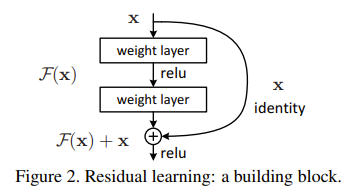

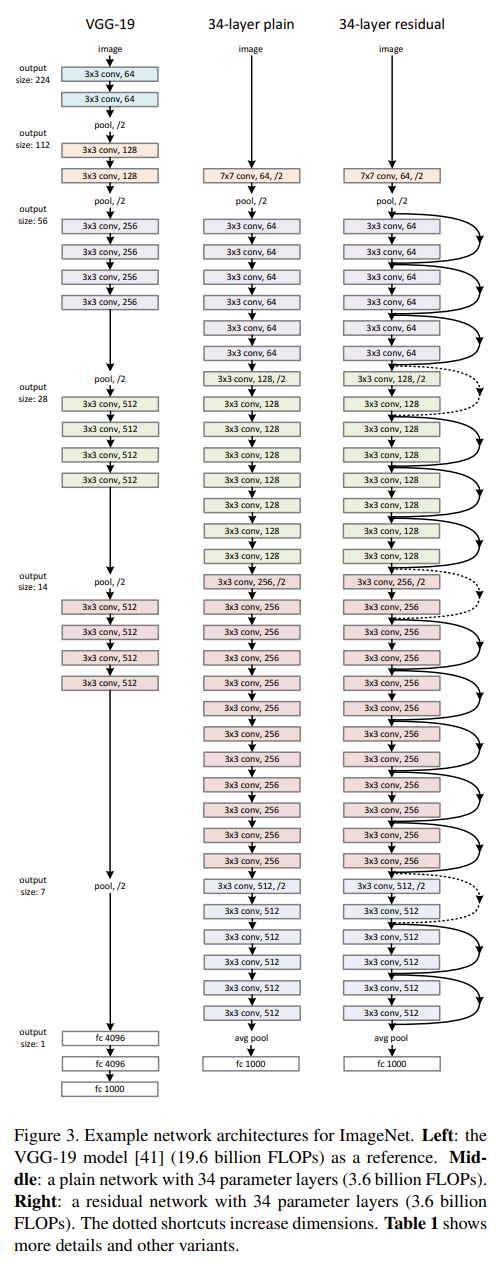

図は [ResNet の原著論文][1] より引用  

[1]: https://doi.org/10.48550/arXiv.1512.03385

# 6. 高速化と演算精度のビット削減

ディープラーニングの計算を高速化するために、GPU の利用や演算精度の削減が検討される  

GPU：大量の積和演算を並列に実行可能  

ビット削減：16 ビットの半精度浮動小数点数 (half float) を用いても、学習に大きな支障がないことが分かっている  

# ch08/half_float_network.py

In [ ]:
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False)

network = DeepConvNet()
network.load_params("../ch08/deep_convnet_params.pkl")

sampled = 10000 # 高速化のため
x_test = x_test[:sampled]
t_test = t_test[:sampled]

print("caluculate accuracy (float64) ... ")
print(network.accuracy(x_test, t_test))

# float16に型変換
x_test = x_test.astype(np.float16)
for param in network.params.values():
    param[...] = param.astype(np.float16)

print("caluculate accuracy (float16) ... ")
print(network.accuracy(x_test, t_test))


# 7. ディープラーニングの実用例と未来

最後に、画像認識以外の応用例を紹介する  

- 物体検出：画像中のどこに何があるかを特定 (R-CNN など)  

- セグメンテーション：ピクセルレベルでクラス分類 (FCN など)  

- 画像キャプション生成：画像から説明文を生成 (NIC：CNN + RNN)  

- 画像生成：何もないところから新しい画像を生成 (DCGAN など)  

- 強化学習：試行錯誤を通して自律的に学習 (DQN など)  

## Regions with CNN features (R-CNN)

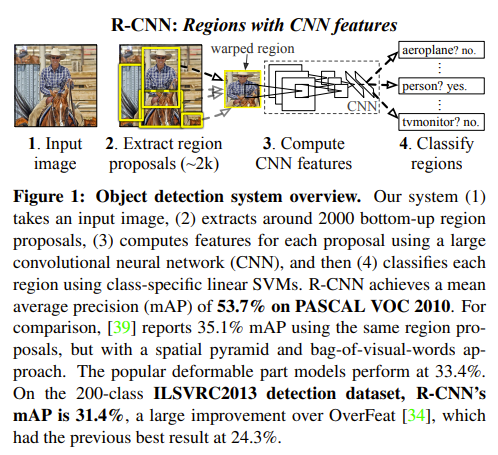

図は [R-CNN の原著論文][2] より引用  

[2]: https://doi.org/10.48550/arXiv.1311.2524

## Fully Convolutional Network (FCN)

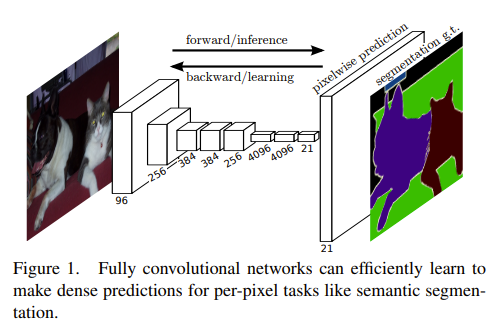

図は [FCN の原著論文][3] より引用  

[3]: https://doi.org/10.48550/arXiv.1411.4038

## Neural Image Caption (NIC)

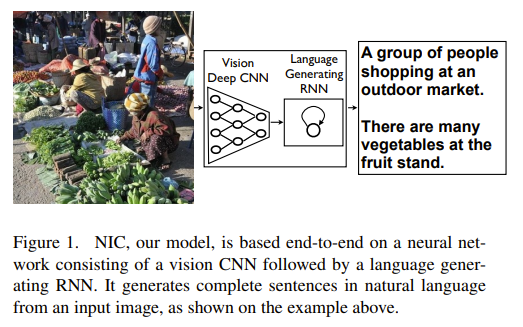

図は [NIC の原著論文][4] より引用  

[4]: https://doi.org/10.48550/arXiv.1411.4555

## Deep Convolutional Generative Adversarial Network (DCGAN)

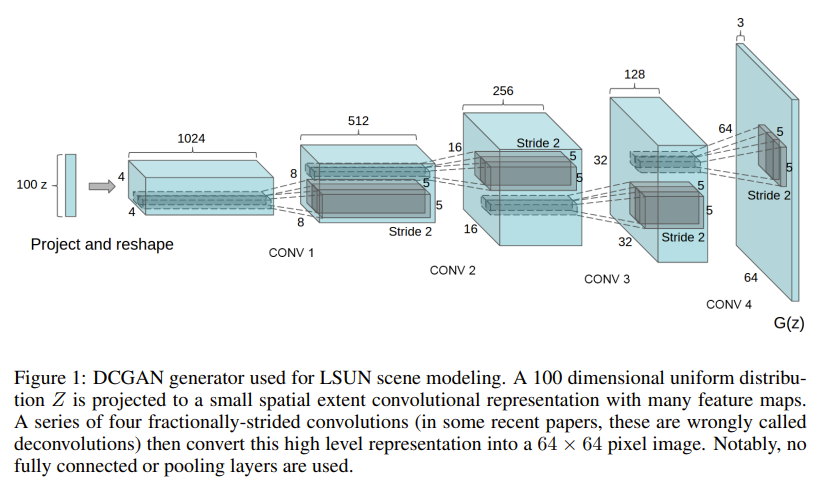

図は [DCGAN の原著論文][5] より引用  

[5]: https://doi.org/10.48550/arXiv.1511.06434

## Deep Q-Network (DQN)

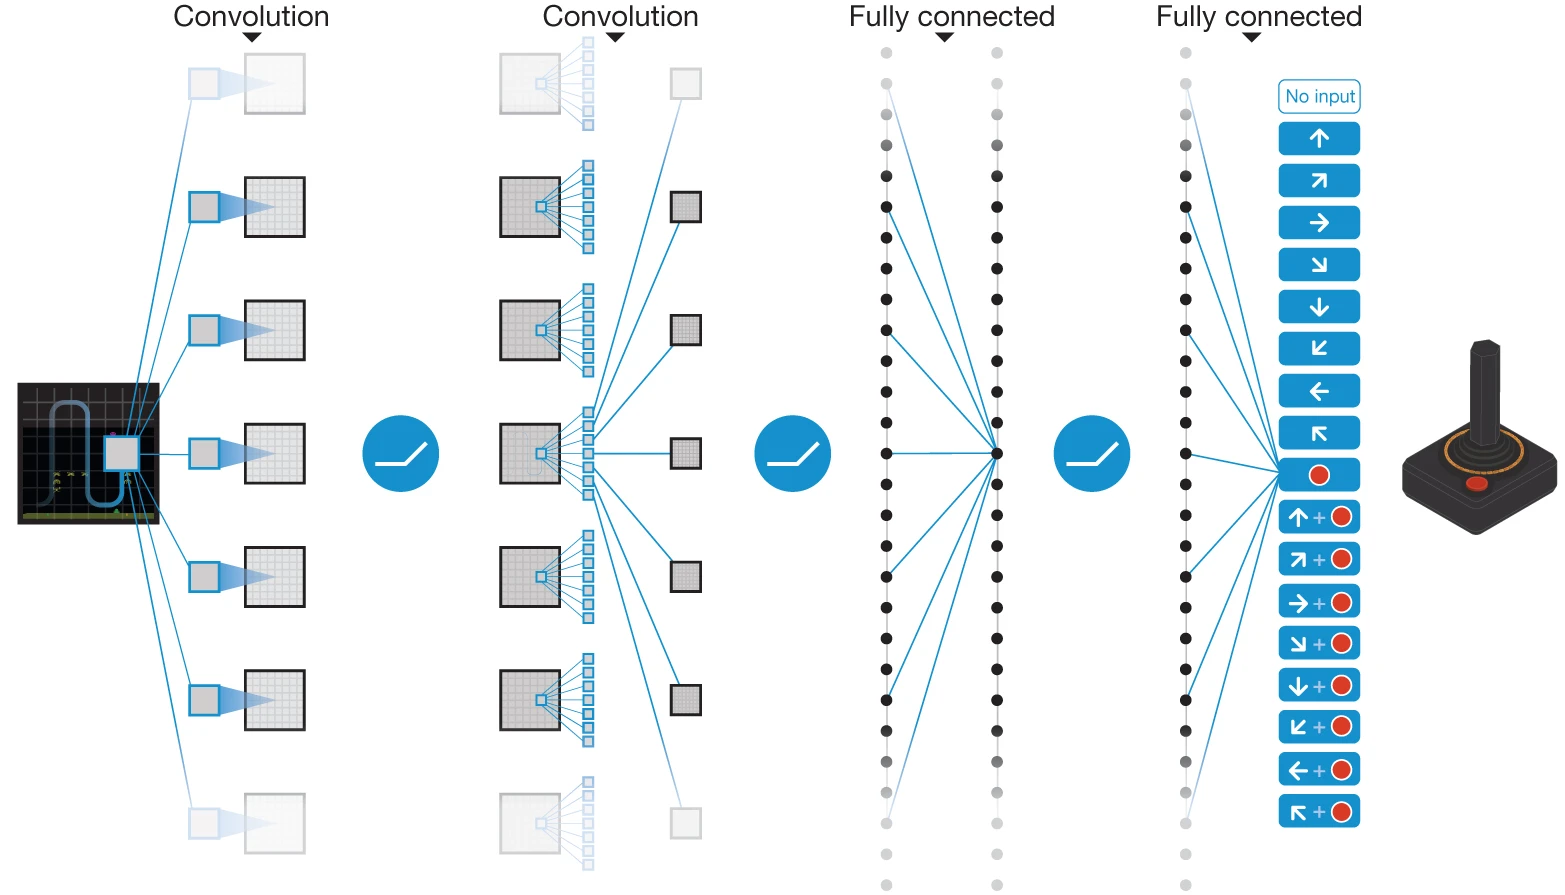

図は [DQN の原著論文][6] より引用  

[6]: https://doi.org/10.1038/nature14236